In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

%matplotlib inline

In [3]:
# Normal data
X1 = np.random.randn(100, 2)

# Outliers
X2 = np.random.uniform(low=-5, high=5, size=(15, 2))

# Combine
X = np.vstack((X1, X2))

In [5]:
dist_matrix = cdist(X, X)

In [7]:
k = 10

# sort distances for each point
sorted_dist = np.sort(dist_matrix, axis=1)

# take average distance to k neighbors
local_density = np.mean(sorted_dist[:, 1:k+1], axis=1)

In [9]:
# Normalize density into probability (0–1)
loop_score = (local_density - np.min(local_density)) / (np.max(local_density) - np.min(local_density))

In [11]:
threshold = 0.7  # higher = more outlier

outliers = X[loop_score > threshold]
normal = X[loop_score <= threshold]

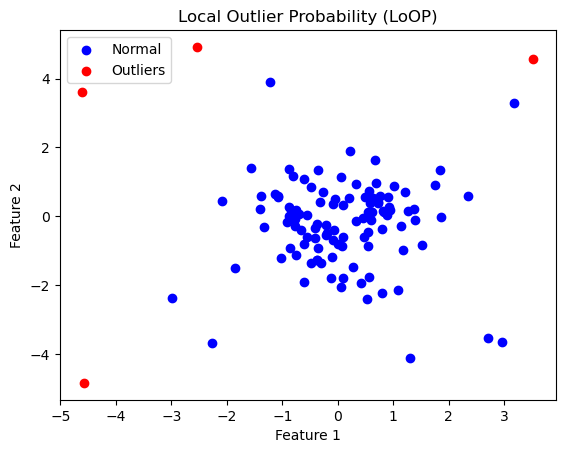

In [13]:
plt.scatter(normal[:,0], normal[:,1], color='blue', label='Normal')
plt.scatter(outliers[:,0], outliers[:,1], color='red', label='Outliers')

plt.title("Local Outlier Probability (LoOP)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()